## makeover monday 2026-03-09

### mario game sales

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel('https://query.data.world/s/wwmm4m4wg6rixm5zm6r54rf2t5c6j4?dws=00000')
df.tail(2)

,Title,Year,Console,Sales (Units),Gross (est.)
85,Super Mario Bros. Wonder + Meetup in Bellabel ...,2026.0,Switch 2,NaN,NaN
86,Total sales,NaN,All Consoles,459665077.0,2.732530e+10


In [10]:
# --- Cleaning ---

# --- Ensure numeric columns are usable ---
df["Sales (Units)"] = pd.to_numeric(df["Sales (Units)"], errors="coerce")
df["Gross (est.)"] = pd.to_numeric(df["Gross (est.)"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# --- Drop rows without meaningful sales ---
df = df.dropna(subset=["Sales (Units)"])

In [11]:
# --- Aggregations ---

# Top 10 games by sales
top_games = df.nlargest(10, "Sales (Units)")

# Sales by console
sales_by_console = (
    df.groupby("Console")["Sales (Units)"]
    .sum()
    .sort_values(ascending=False)
)

# Sales over time
sales_by_year = (
    df.groupby("Year")["Sales (Units)"]
    .sum()
    .sort_index()
)

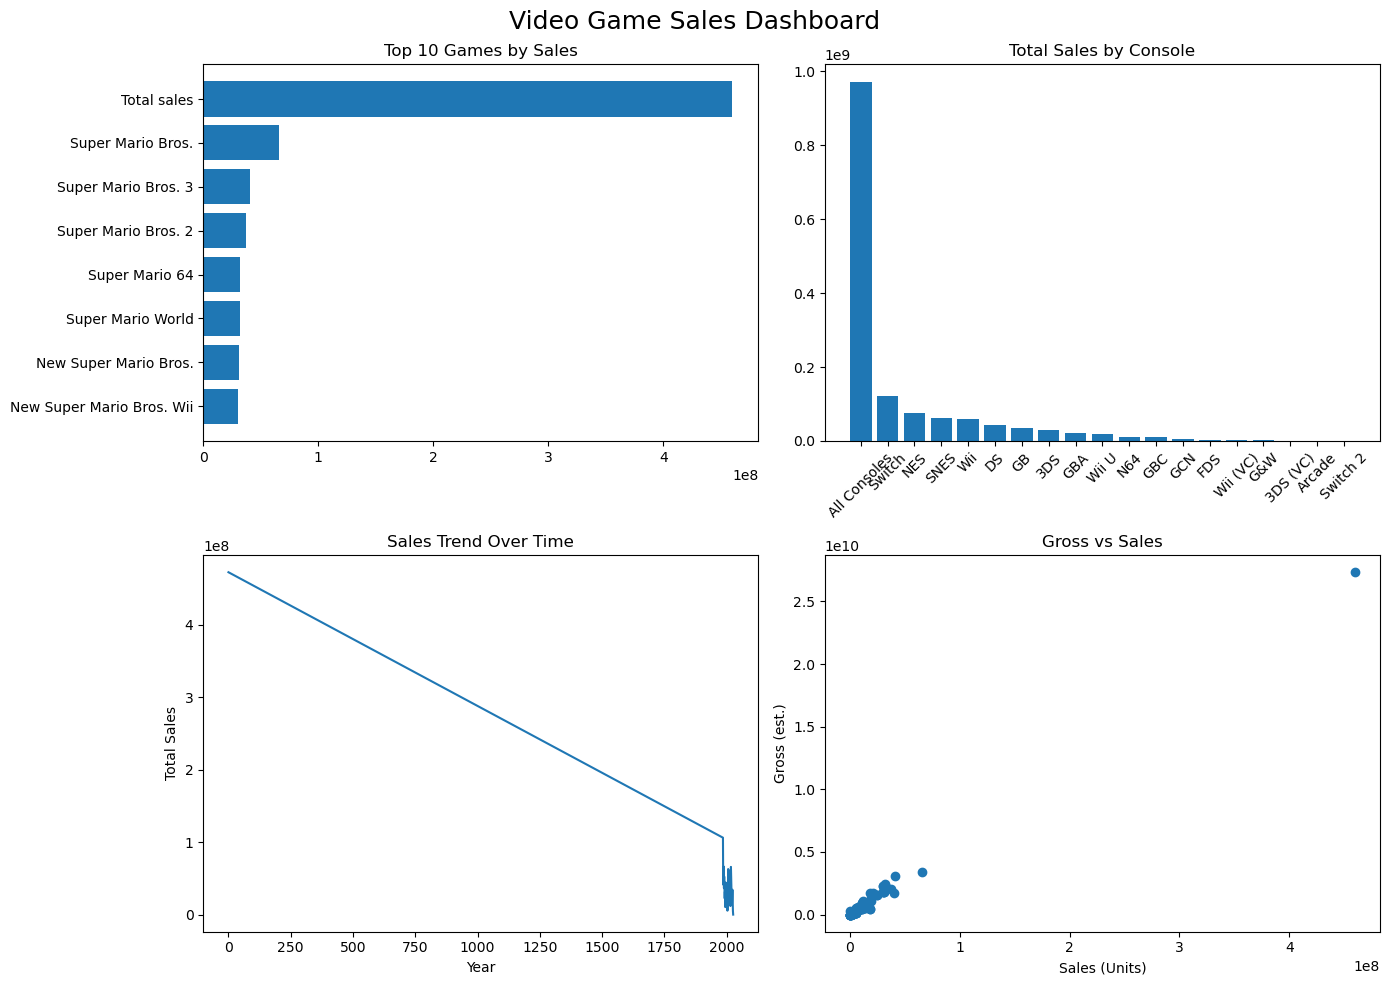

In [12]:
# --- Create 2x2 layout ---
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# --- Chart 1: Top 10 Games ---
axs[0, 0].barh(top_games["Title"], top_games["Sales (Units)"])
axs[0, 0].set_title("Top 10 Games by Sales")
axs[0, 0].invert_yaxis()

# --- Chart 2: Sales by Console ---
axs[0, 1].bar(sales_by_console.index, sales_by_console.values)
axs[0, 1].set_title("Total Sales by Console")
axs[0, 1].tick_params(axis='x', rotation=45)

# --- Chart 3: Sales Trend Over Time ---
axs[1, 0].plot(sales_by_year.index, sales_by_year.values)
axs[1, 0].set_title("Sales Trend Over Time")
axs[1, 0].set_xlabel("Year")
axs[1, 0].set_ylabel("Total Sales")

# --- Chart 4: Gross vs Sales Scatter ---
axs[1, 1].scatter(df["Sales (Units)"], df["Gross (est.)"])
axs[1, 1].set_title("Gross vs Sales")
axs[1, 1].set_xlabel("Sales (Units)")
axs[1, 1].set_ylabel("Gross (est.)")

# --- Suptitle ---
fig.suptitle("Video Game Sales Dashboard", fontsize=18)

# --- Layout ---
plt.tight_layout()

# --- Show ---
plt.show()